Test Accuracy with all features: 0.6686390532544378
Test Precision with all features: 0.6555555555555556
Test Recall with all features: 0.7023809523809523
Test F1 Score with all features: 0.6781609195402298
Cross-validation Accuracy scores: [0.71851852 0.66666667 0.63703704 0.63432836 0.63432836]
Average cross-validation Accuracy score: 0.6581757877280265


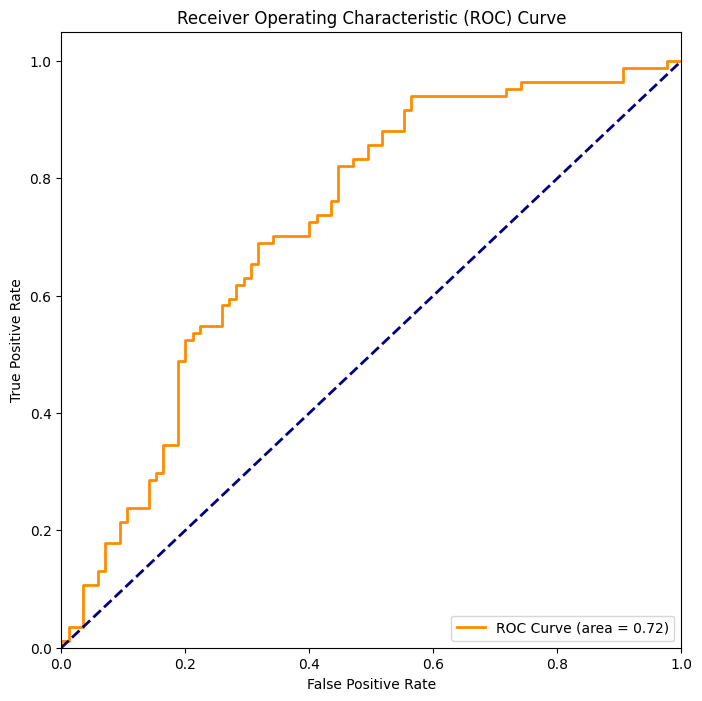

In [1]:
import numpy as np
# Correcting the code as per your requirements. This will include evaluation metrics for a classification problem.
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Loading the dataset
df = pd.read_csv('datasets/Preprocessed_csv.csv')

if 'first_derivative' in df.columns and 'second_derivative' in df.columns:
    df = df.drop(columns=['first_derivative', 'second_derivative', 'historical_volatility', 'daily_return'])

all_features = df.select_dtypes(include=[np.number]).drop(columns=['target'])
target = df['target']

x_train_all, x_test_all, y_train_all, y_test_all = train_test_split(
    all_features, target, test_size=0.2, random_state=123
)

model_all = XGBClassifier(random_state=123, n_estimators=16, max_depth=12)
model_all.fit(x_train_all, y_train_all)

y_predicted_train_all = model_all.predict(x_train_all)
y_predicted_test_all = model_all.predict(x_test_all)

accuracy_train_all = accuracy_score(y_train_all, y_predicted_train_all)
precision_train_all = precision_score(y_train_all, y_predicted_train_all)
recall_train_all = recall_score(y_train_all, y_predicted_train_all)
f1_train_all = f1_score(y_train_all, y_predicted_train_all)

accuracy_test_all = accuracy_score(y_test_all, y_predicted_test_all)
precision_test_all = precision_score(y_test_all, y_predicted_test_all)
recall_test_all = recall_score(y_test_all, y_predicted_test_all)
f1_test_all = f1_score(y_test_all, y_predicted_test_all)


print("Test Accuracy with all features:", accuracy_test_all)
print("Test Precision with all features:", precision_test_all)
print("Test Recall with all features:", recall_test_all)
print("Test F1 Score with all features:", f1_test_all)

cv_accuracy_scores = cross_val_score(model_all, x_train_all, y_train_all, cv=5, scoring='accuracy')
print("Cross-validation Accuracy scores:", cv_accuracy_scores)
print("Average cross-validation Accuracy score:", np.mean(cv_accuracy_scores))

y_proba_test_all = model_all.predict_proba(x_test_all)[:, 1]

fpr, tpr, _ = roc_curve(y_test_all, y_proba_test_all)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()



In [2]:
df.head()

,Date,clean_text,favorite_count,full_text,reply_count,retweet_count,entity_vectors,clean_text_vector,importance_coefficient,importance_coefficient_normalized,...,negative_sentiment_score,positive_sentiment_score,neutral_sentiment_score,Open,High,Low,Close,Adj Close,Volume,target
0,2021-02-01,sent givedirectly great work distributing fund...,3496.0,i sent some! https://t.co/mfyrz35zjf\n\nyou sh...,731.0,686,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[ 6.55804798e-02 -4.08827849e-02 5.29426113e-...,8043.5,0.013905,...,0.000,0.000,1.000,33114.58,34638.21,32384.23,33537.18,33537.18,61400400660,1
1,2021-02-02,watch video learn truth doublespend separate f...,109.0,watch this video to learn the truth about what...,5.0,25,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[ 4.15213443e-02 -1.58386230e-02 -1.94963720e-...,245.5,0.000424,...,0.000,0.075,0.925,33533.20,35896.88,33489.22,35510.29,35510.29,63088585433,1
2,2021-02-03,min video review strategy simple advanced help...,153.0,"in this 7min video, i review strategies from s...",9.0,24,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[-0.0159668 0.06502838 -0.05678711 0.042077...,334.5,0.000578,...,0.000,0.136,0.864,35510.82,37480.19,35443.98,37472.09,37472.09,61166818159,1
3,2021-02-04,fair elon gave chance load bag early,196.0,to be fair elon gave all of you the chance to ...,31.0,18,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[ 9.04134139e-02 9.13085938e-02 1.20035803e-...,425.5,0.000736,...,0.098,0.000,0.902,37475.11,38592.18,36317.50,36926.07,36926.07,68838074392,0
4,2021-02-05,minute video ive learned much cant smash like ...,100.0,â30 minutes into the video and i've learned ...,7.0,8,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[ 0.02418934 0.05538386 -0.01659463 0.096178...,211.5,0.000366,...,0.075,0.220,0.705,36931.55,38225.91,36658.76,38144.31,38144.31,58598066402,1


Best parameters found: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.9}
Best cross-validation score: 0.66
Test Accuracy with best parameters: 0.6745562130177515
Test Precision with best parameters: 0.6593406593406593
Test Recall with best parameters: 0.7142857142857143
Test F1 Score with best parameters: 0.6857142857142857


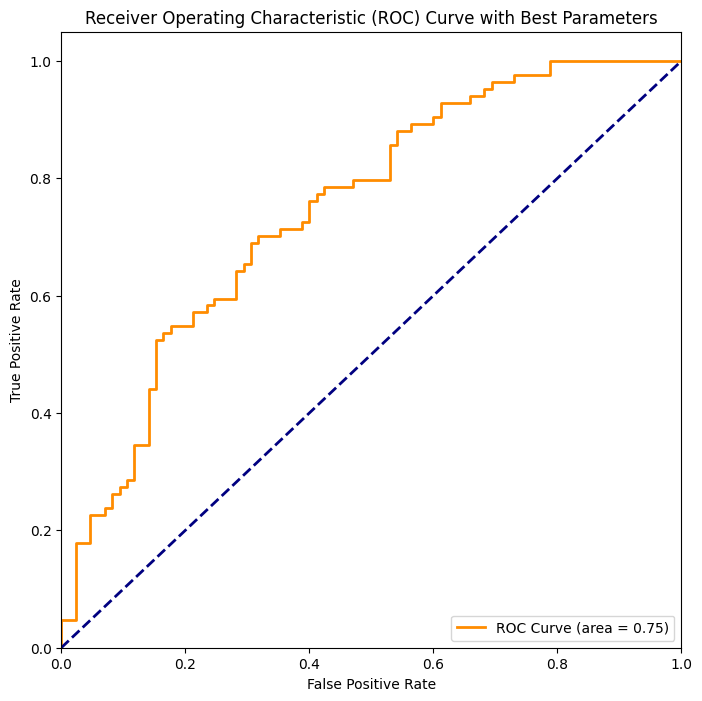

In [3]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 6, 10],
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
}

model = XGBClassifier(random_state=123)

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)

grid_search.fit(x_train_all, y_train_all)

best_parameters = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters found: {best_parameters}")
print(f"Best cross-validation score: {best_score:.2f}")

y_pred_test_best = grid_search.best_estimator_.predict(x_test_all)

accuracy_test_best = accuracy_score(y_test_all, y_pred_test_best)
precision_test_best = precision_score(y_test_all, y_pred_test_best)
recall_test_best = recall_score(y_test_all, y_pred_test_best)
f1_test_best = f1_score(y_test_all, y_pred_test_best)

print("Test Accuracy with best parameters:", accuracy_test_best)
print("Test Precision with best parameters:", precision_test_best)
print("Test Recall with best parameters:", recall_test_best)
print("Test F1 Score with best parameters:", f1_test_best)

y_proba_test_best = grid_search.best_estimator_.predict_proba(x_test_all)[:, 1]

fpr_best, tpr_best, _ = roc_curve(y_test_all, y_proba_test_best)
roc_auc_best = auc(fpr_best, tpr_best)

plt.figure(figsize=(8, 8))
plt.plot(fpr_best, tpr_best, color='darkorange', lw=2, label=f'ROC Curve (area = {roc_auc_best:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve with Best Parameters')
plt.legend(loc="lower right")
plt.show()



/home/meril/Documents/UPM/dataMining/venv2/lib/python3.11/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/meril/Documents/UPM/dataMining/venv2/lib/python3.11/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/meril/Documents/UPM/dataMining/venv2/lib/python3.11/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/meril/Documents/UPM/dataMining/venv2/lib/python3.11/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/meril/Documents/UPM/dataMining/venv2/lib/python3.11/site-packages/sklearn/ensemble/_base.py:156: FutureWar

Best parameters found: {'base_estimator__max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 200}
Best cross-validation score: 0.74
Test Accuracy with best parameters: 0.7337278106508875
Test Precision with best parameters: 0.7142857142857143
Test Recall with best parameters: 0.7738095238095238
Test F1 Score with best parameters: 0.7428571428571429


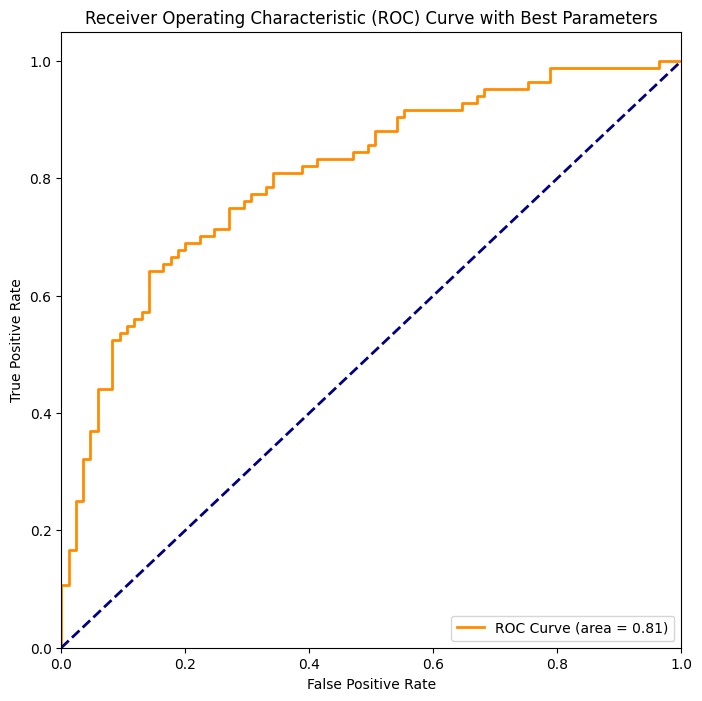

In [4]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('datasets/Preprocessed_csv.csv')

# Dropping unnecessary columns
if 'first_derivative' in df.columns and 'second_derivative' in df.columns:
    df = df.drop(columns=['first_derivative', 'second_derivative', 'historical_volatility', 'daily_return'])

all_features = df.select_dtypes(include=[np.number]).drop(columns=['target'])
target = df['target']

x_train_all, x_test_all, y_train_all, y_test_all = train_test_split(
    all_features, target, test_size=0.2, random_state=123
)

param_grid = {
    'base_estimator__max_depth': [1, 2, 3],
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
}

base_estimator = DecisionTreeClassifier(random_state=123)

model = AdaBoostClassifier(base_estimator=base_estimator, random_state=123)

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train_all, y_train_all)

best_parameters = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters found: {best_parameters}")
print(f"Best cross-validation score: {best_score:.2f}")

y_pred_test_best = grid_search.best_estimator_.predict(x_test_all)

accuracy_test_best = accuracy_score(y_test_all, y_pred_test_best)
precision_test_best = precision_score(y_test_all, y_pred_test_best)
recall_test_best = recall_score(y_test_all, y_pred_test_best)
f1_test_best = f1_score(y_test_all, y_pred_test_best)

print("Test Accuracy with best parameters:", accuracy_test_best)
print("Test Precision with best parameters:", precision_test_best)
print("Test Recall with best parameters:", recall_test_best)
print("Test F1 Score with best parameters:", f1_test_best)

y_proba_test_best = grid_search.best_estimator_.predict_proba(x_test_all)[:, 1]
fpr_best, tpr_best, _ = roc_curve(y_test_all, y_proba_test_best)
roc_auc_best = auc(fpr_best, tpr_best)

plt.figure(figsize=(8, 8))
plt.plot(fpr_best, tpr_best, color='darkorange', lw=2, label=f'ROC Curve (area = {roc_auc_best:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve with Best Parameters')
plt.legend(loc="lower right")
plt.show()

